In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import re
import ast
import time

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

import tensorflow as tf
from tensorflow import keras

In [2]:
SCHEDULER_PATH = "scheduler_data.csv"
DCGM_PATH = "dcgm.csv"

scheduler_df = pd.read_csv(SCHEDULER_PATH)
dcgm_df = pd.read_csv(DCGM_PATH)

print("scheduler_df:", scheduler_df.shape)
print("dcgm_df:", dcgm_df.shape)

display(scheduler_df.head())
display(dcgm_df.head())

scheduler_df: (287173, 31)
dcgm_df: (96893, 23)


,id_array_job,id_array_task,id_user,kill_requid,nodes_alloc,nodelist,cpus_req,derived_ec,exit_code,gres_req,...,time_submit,time_eligible,time_start,time_end,time_suspended,track_steps,tres_alloc,tres_req,job_type,id_job
0,41161693674,4595979483,66088413977,51671871839,0,[],1,0,256,NaN,...,3014,3014,3014,3014,-1,0,NaN,"1=1,2=5000,4=1,5=1,1002=2",OTHER,13715936505
1,41161693674,4595979483,66088413977,51671871839,1,['r2684277-n303509'],1,0,0,gpu:volta:2,...,3022,3022,3022,3025,-1,0,"1=1,2=9600,4=1,5=1,1002=2","1=1,2=9600,4=1,5=1,1002=2",OTHER,25780056187
2,41161693674,4595979483,16176946191,51671871839,1,['r5198790-n347934'],4,32512,32512,gpu:volta:1,...,5682,5682,5683,5684,-1,0,"1=4,2=38400,4=1,5=4,1002=1","1=4,2=38400,4=1,5=4,1002=1",OTHER,53722449986
3,41161693674,4595979483,16176946191,16176946191,1,['r3541344-n655125'],4,0,0,gpu:volta:1,...,34467,34467,34468,34548,-1,0,"1=4,2=20000,4=1,5=4,1002=1","1=4,2=20000,4=1,5=4,1002=1",OTHER,19989272070
4,41161693674,4595979483,16176946191,16176946191,1,['r3541344-n655125'],4,0,0,gpu:volta:1,...,34596,34596,34596,35108,-1,0,"1=4,2=20000,4=1,5=4,1002=1","1=4,2=20000,4=1,5=4,1002=1",OTHER,49220239266


,Node,avgmemoryutilization_pct,avgsmutilization_pct,energyconsumed_joules,gpu_id,maxgpumemoryused_bytes,memoryutilization_pct_avg,memoryutilization_pct_max,memoryutilization_pct_min,pcierxbandwidth_megabytes_avg,...,pcietxbandwidth_megabytes_max,pcietxbandwidth_megabytes_min,powerusage_watts_avg,powerusage_watts_max,powerusage_watts_min,smutilization_pct_avg,smutilization_pct_max,smutilization_pct_min,totalexecutiontime_sec,id_job
0,r9170217-n750018,0.0,1.0,157521.0,0,2.645557e+09,3.0,24.0,0.0,1646.0,...,1530.0,676.0,44.0546,156.962,25.468,11.0,64.0,0.0,4452.47,4393785332
1,r44132-n469339,0.0,0.0,0.0,1,0.000000e+00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0000,0.000,0.000,0.0,0.0,0.0,0.54,18177101425
2,r5354770-n172107,0.0,3.0,94816.0,0,2.917171e+07,0.0,0.0,0.0,1846.0,...,1872.0,1346.0,26.3725,27.483,25.979,6.0,43.0,0.0,8398.30,39529488078
3,r1900814-n772143,0.0,0.0,69451.0,0,1.527587e+09,0.0,1.0,0.0,539.0,...,337.0,293.0,37.5481,52.039,26.676,1.0,25.0,0.0,1851.72,19994333952
4,r9515777-n469339,0.0,0.0,0.0,1,0.000000e+00,0.0,0.0,0.0,1991.0,...,1109.0,1109.0,25.0320,25.032,25.032,0.0,0.0,0.0,0.99,397881706


In [3]:
print("Scheduler columns:")
print(scheduler_df.columns.tolist())

print("\nDCGM columns:")
print(dcgm_df.columns.tolist())

Scheduler columns:
['id_array_job', 'id_array_task', 'id_user', 'kill_requid', 'nodes_alloc', 'nodelist', 'cpus_req', 'derived_ec', 'exit_code', 'gres_req', 'gres_alloc', 'gres_used', 'array_max_tasks', 'array_task_pending', 'constraints', 'flags', 'mem_req', 'partition', 'priority', 'state', 'timelimit', 'time_submit', 'time_eligible', 'time_start', 'time_end', 'time_suspended', 'track_steps', 'tres_alloc', 'tres_req', 'job_type', 'id_job']

DCGM columns:
['Node', 'avgmemoryutilization_pct', 'avgsmutilization_pct', 'energyconsumed_joules', 'gpu_id', 'maxgpumemoryused_bytes', 'memoryutilization_pct_avg', 'memoryutilization_pct_max', 'memoryutilization_pct_min', 'pcierxbandwidth_megabytes_avg', 'pcierxbandwidth_megabytes_max', 'pcierxbandwidth_megabytes_min', 'pcietxbandwidth_megabytes_avg', 'pcietxbandwidth_megabytes_max', 'pcietxbandwidth_megabytes_min', 'powerusage_watts_avg', 'powerusage_watts_max', 'powerusage_watts_min', 'smutilization_pct_avg', 'smutilization_pct_max', 'smutiliza

In [4]:
print("Scheduler duplicates:", scheduler_df.duplicated().sum())
print("DCGM duplicates:", dcgm_df.duplicated().sum())

scheduler_df = scheduler_df.drop_duplicates().reset_index(drop=True)
dcgm_df = dcgm_df.drop_duplicates().reset_index(drop=True)

print("After dedupe scheduler_df:", scheduler_df.shape)
print("After dedupe dcgm_df:", dcgm_df.shape)

print("\nScheduler missing (top 15):")
display(scheduler_df.isna().sum().sort_values(ascending=False).head(15))

print("\nDCGM missing (top 15):")
display(dcgm_df.isna().sum().sort_values(ascending=False).head(15))

Scheduler duplicates: 0
DCGM duplicates: 0
After dedupe scheduler_df: (287173, 31)
After dedupe dcgm_df: (96893, 23)

Scheduler missing (top 15):


gres_used         287173
tres_alloc         70523
gres_req           70497
gres_alloc         70497
id_array_job           0
state                  0
timelimit              0
time_submit            0
time_eligible          0
time_start             0
partition              0
time_end               0
time_suspended         0
track_steps            0
tres_req               0
dtype: int64


DCGM missing (top 15):


Node                             0
pcietxbandwidth_megabytes_avg    0
totalexecutiontime_sec           0
smutilization_pct_min            0
smutilization_pct_max            0
smutilization_pct_avg            0
powerusage_watts_min             0
powerusage_watts_max             0
powerusage_watts_avg             0
pcietxbandwidth_megabytes_min    0
pcietxbandwidth_megabytes_max    0
pcierxbandwidth_megabytes_min    0
avgmemoryutilization_pct         0
pcierxbandwidth_megabytes_max    0
pcierxbandwidth_megabytes_avg    0
dtype: int64

In [5]:
scheduler_df = scheduler_df.copy()

# Keep only jobs with valid start/end times
scheduler_df = scheduler_df[(scheduler_df["time_start"] >= 0) & (scheduler_df["time_end"] >= 0)].reset_index(drop=True)

print("After keeping completed jobs:", scheduler_df.shape)

After keeping completed jobs: (217738, 31)


In [6]:
def parse_gpu_count(gres_str):
    if pd.isna(gres_str):
        return 0
    s = str(gres_str).lower()
    if "gpu" not in s:
        return 0
    
    nums = re.findall(r"gpu(?::[a-z0-9_-]+)*:(\d+)", s)
    if nums:
        return int(nums[-1])
    
    fallback_nums = re.findall(r"(\d+)", s)
    return int(fallback_nums[0]) if fallback_nums else 0

scheduler_df["job_duration_sec"] = scheduler_df["time_end"] - scheduler_df["time_start"]
scheduler_df["queue_wait_sec"] = scheduler_df["time_start"] - scheduler_df["time_submit"]

scheduler_df["gpus_req_count"] = scheduler_df["gres_req"].apply(parse_gpu_count)
scheduler_df["gpus_alloc_count"] = scheduler_df["gres_alloc"].apply(parse_gpu_count)

# remove negatives (safety)
scheduler_df = scheduler_df[(scheduler_df["job_duration_sec"] >= 0) & (scheduler_df["queue_wait_sec"] >= 0)].reset_index(drop=True)

display(scheduler_df[["job_duration_sec","queue_wait_sec","gpus_req_count","gpus_alloc_count"]].describe())

,job_duration_sec,queue_wait_sec,gpus_req_count,gpus_alloc_count
count,2.177380e+05,2.177380e+05,217738.000000,217738.000000
mean,1.193218e+04,2.943638e+03,3.030840,3.030840
std,6.462811e+04,2.091087e+04,29.265951,29.265951
min,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,1.500000e+01,1.000000e+00,1.000000,1.000000
50%,1.280000e+02,6.000000e+00,1.000000,1.000000
75%,1.360000e+03,6.040000e+02,1.000000,1.000000
max,3.174114e+06,1.051208e+06,870.000000,870.000000


In [7]:
print("DCGM columns:")
for c in dcgm_df.columns:
    print("-", c)

DCGM columns:
- Node
- avgmemoryutilization_pct
- avgsmutilization_pct
- energyconsumed_joules
- gpu_id
- maxgpumemoryused_bytes
- memoryutilization_pct_avg
- memoryutilization_pct_max
- memoryutilization_pct_min
- pcierxbandwidth_megabytes_avg
- pcierxbandwidth_megabytes_max
- pcierxbandwidth_megabytes_min
- pcietxbandwidth_megabytes_avg
- pcietxbandwidth_megabytes_max
- pcietxbandwidth_megabytes_min
- powerusage_watts_avg
- powerusage_watts_max
- powerusage_watts_min
- smutilization_pct_avg
- smutilization_pct_max
- smutilization_pct_min
- totalexecutiontime_sec
- id_job


In [8]:
dcgm_agg = (
    dcgm_df.groupby("Node", as_index=False)
    .agg({
        "avgsmutilization_pct": "mean",
        "avgmemoryutilization_pct": "mean",
        "powerusage_watts_avg": "mean"
    })
    .rename(columns={
        "avgsmutilization_pct": "node_gpu_sm_util_mean",
        "avgmemoryutilization_pct": "node_gpu_mem_util_mean",
        "powerusage_watts_avg": "node_gpu_power_watts_mean"
    })
)

print("dcgm_agg:", dcgm_agg.shape)
display(dcgm_agg.head())

dcgm_agg: (225, 4)


,Node,node_gpu_sm_util_mean,node_gpu_mem_util_mean,node_gpu_power_watts_mean
0,r1039410-n172107,35.188119,12.843234,100.496809
1,r1039410-n200569,21.782152,5.931759,57.723382
2,r1039410-n303509,16.730603,5.909483,55.695469
3,r1039410-n717709,28.787281,8.559211,73.515713
4,r1039410-n750018,14.080645,5.754032,50.534907


In [9]:
def extract_first_node(nodelist):
    if pd.isna(nodelist):
        return np.nan

    s = str(nodelist).strip()
    if s in ("[]", "", "nan", "None"):
        return np.nan

    # parse "['r268...-n303...']"
    try:
        val = ast.literal_eval(s)
        if isinstance(val, list):
            return val[0] if len(val) > 0 else np.nan
        if isinstance(val, str):
            return val
    except Exception:
        pass

    # fallback extract r###-n###
    m = re.search(r"(r\d+-n\d+)", s)
    return m.group(1) if m else np.nan

scheduler_df["node_key"] = scheduler_df["nodelist"].apply(extract_first_node)

print("node_key missing %:", scheduler_df["node_key"].isna().mean().round(4))
display(scheduler_df[["nodelist","node_key"]].head(10))

node_key missing %: 0.0058


,nodelist,node_key
0,[],NaN
1,['r2684277-n303509'],r2684277-n303509
2,['r5198790-n347934'],r5198790-n347934
3,['r3541344-n655125'],r3541344-n655125
4,['r3541344-n655125'],r3541344-n655125
5,['r3541344-n655125'],r3541344-n655125
6,['r3541344-n655125'],r3541344-n655125
7,['r3541344-n655125'],r3541344-n655125
8,[],NaN
9,['r5198790-n347934'],r5198790-n347934


In [10]:
scheduler_df = scheduler_df.merge(
    dcgm_agg,
    how="left",
    left_on="node_key",
    right_on="Node"
).drop(columns=["Node"], errors="ignore")

print("After DCGM merge:", scheduler_df.shape)

gpu_cols = [c for c in scheduler_df.columns if c.startswith("node_gpu_")]
print("GPU columns:", gpu_cols)

display(scheduler_df[["node_key"] + gpu_cols].head(10))

After DCGM merge: (217738, 39)
GPU columns: ['node_gpu_sm_util_mean', 'node_gpu_mem_util_mean', 'node_gpu_power_watts_mean']


,node_key,node_gpu_sm_util_mean,node_gpu_mem_util_mean,node_gpu_power_watts_mean
0,NaN,NaN,NaN,NaN
1,r2684277-n303509,15.366171,6.085502,52.329193
2,r5198790-n347934,NaN,NaN,NaN
3,r3541344-n655125,NaN,NaN,NaN
4,r3541344-n655125,NaN,NaN,NaN
5,r3541344-n655125,NaN,NaN,NaN
6,r3541344-n655125,NaN,NaN,NaN
7,r3541344-n655125,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN
9,r5198790-n347934,NaN,NaN,NaN


In [11]:
print("Numeric summary:")
display(scheduler_df.describe(include=[np.number]).T)

print("\nCategorical summary:")
display(scheduler_df.describe(include=["object"]).T)

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
id_array_job,217738.0,3.846310e+10,9.638425e+09,3.084235e+06,4.116169e+10,4.116169e+10,4.116169e+10,6.708864e+10
id_array_task,217738.0,1.066716e+10,1.508548e+10,2.513347e+06,4.595979e+09,4.595979e+09,4.595979e+09,6.710714e+10
id_user,217738.0,3.991417e+10,1.405470e+10,2.689431e+08,3.899757e+10,4.141598e+10,4.201284e+10,6.701965e+10
kill_requid,217738.0,4.954939e+10,7.494073e+09,2.689431e+08,5.167187e+10,5.167187e+10,5.167187e+10,6.693448e+10
nodes_alloc,217738.0,1.946436e+00,1.460595e+01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.350000e+02
cpus_req,217738.0,1.265924e+01,4.395299e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.600000e+01,1.536000e+03
derived_ec,217738.0,6.726628e+01,1.202804e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.528000e+04
exit_code,217738.0,1.022426e+03,5.606459e+03,0.000000e+00,0.000000e+00,0.000000e+00,2.560000e+02,6.528000e+04
gres_used,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
array_max_tasks,217738.0,4.032369e-03,1.697007e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.000000e+00



Categorical summary:


,count,unique,top,freq
nodelist,217738,2186,['r9659953-n772143'],2159
gres_req,216466,51,gpu:volta:1,95502
gres_alloc,216466,42,gpu:1,185075
constraints,217738,4,xeon-g6,213992
partition,217738,4,normal,106297
tres_alloc,216465,593,"1=1,2=10240,4=1,5=1,1001=1",75430
tres_req,217738,556,"1=1,2=10240,4=1,5=1,1001=1",75942
job_type,217738,4,OTHER,170884
node_key,216465,379,r9659953-n772143,2162


Classes: 4


job_type
OTHER                170884
LLSUB:BATCH           36857
LLSUB:INTERACTIVE      7506
LLMAPREDUCE:MAP        2491
Name: count, dtype: int64

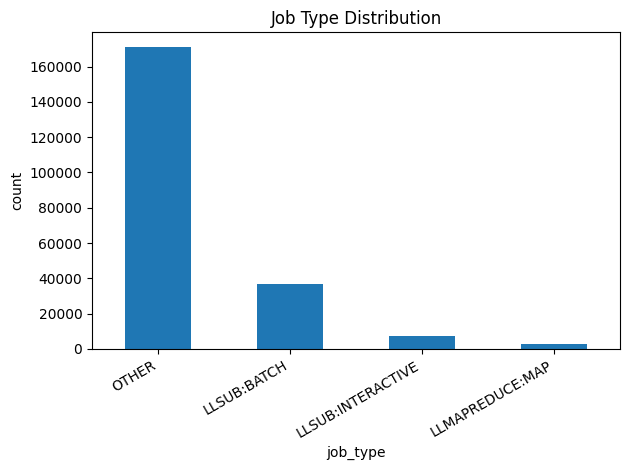

In [12]:
TARGET_COL = "job_type"

print("Classes:", scheduler_df[TARGET_COL].nunique())
display(scheduler_df[TARGET_COL].value_counts())

plt.figure()
scheduler_df[TARGET_COL].value_counts().plot(kind="bar")
plt.title("Job Type Distribution")
plt.xlabel("job_type")
plt.ylabel("count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

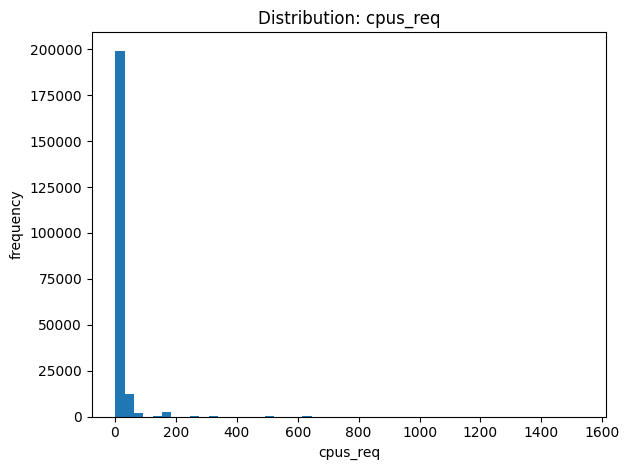

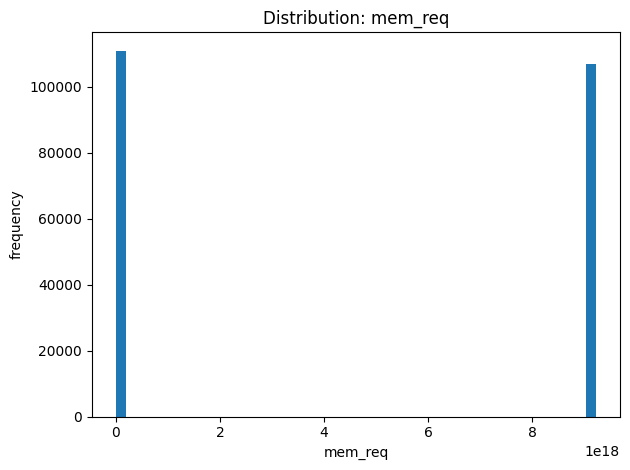

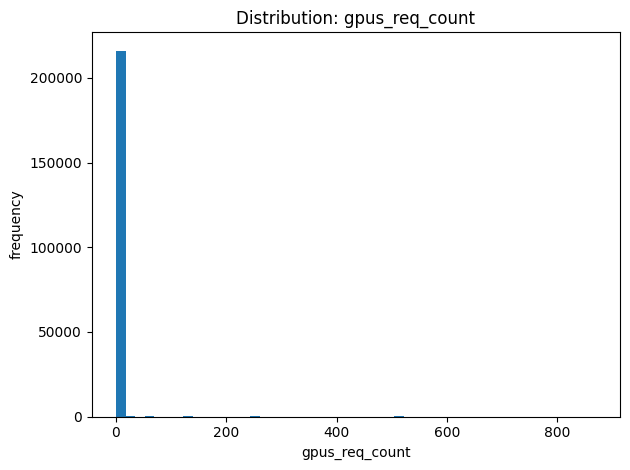

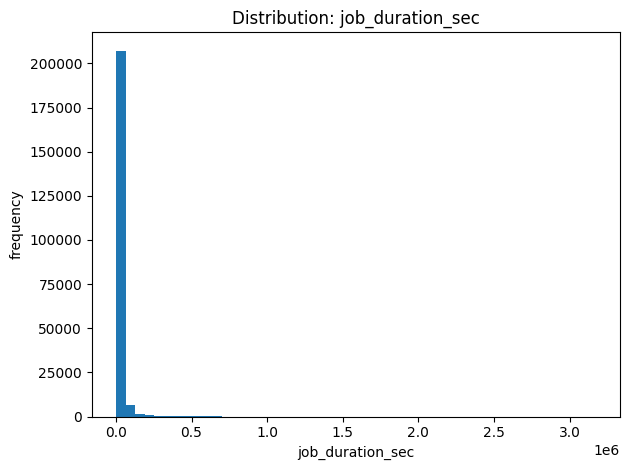

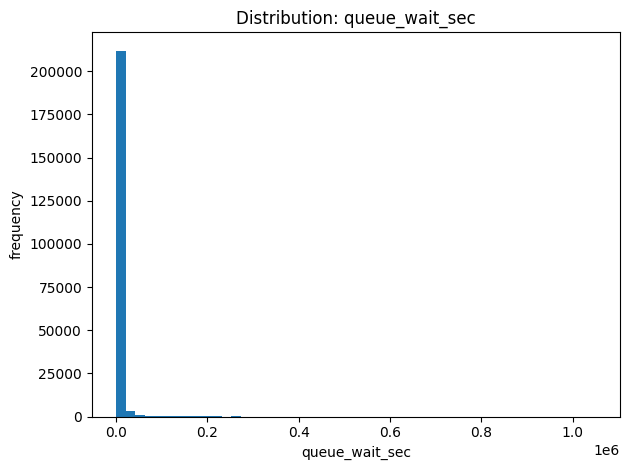

In [13]:
features_to_plot = ["cpus_req", "mem_req", "gpus_req_count", "job_duration_sec", "queue_wait_sec"]

for col in features_to_plot:
    plt.figure()
    scheduler_df[col].replace([np.inf, -np.inf], np.nan).dropna().plot(kind="hist", bins=50)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.tight_layout()
    plt.show()

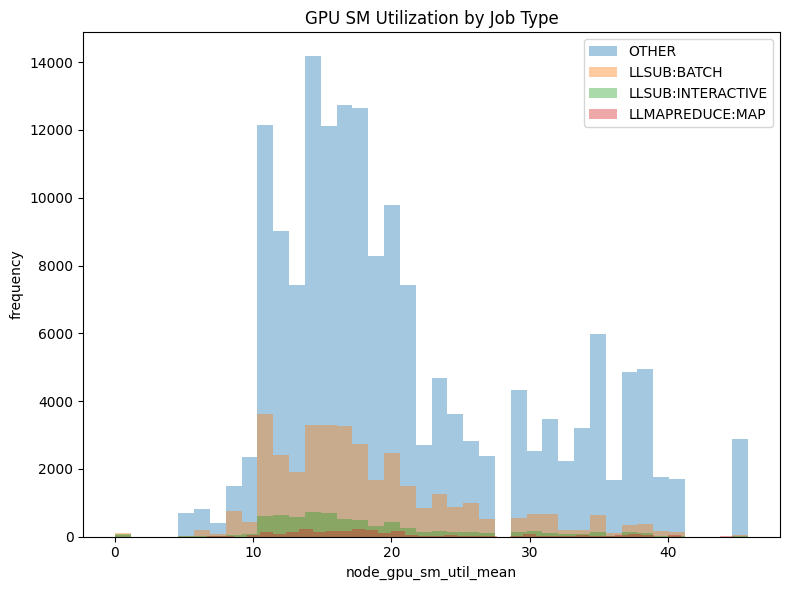

In [14]:
if "node_gpu_sm_util_mean" in scheduler_df.columns:
    plt.figure(figsize=(8,6))
    for jt in scheduler_df[TARGET_COL].unique():
        subset = scheduler_df[scheduler_df[TARGET_COL] == jt]
        plt.hist(subset["node_gpu_sm_util_mean"].dropna(), bins=40, alpha=0.4, label=str(jt))
    plt.legend()
    plt.title("GPU SM Utilization by Job Type")
    plt.xlabel("node_gpu_sm_util_mean")
    plt.ylabel("frequency")
    plt.tight_layout()
    plt.show()
else:
    print("No DCGM GPU columns found, skipping GPU EDA plot.")

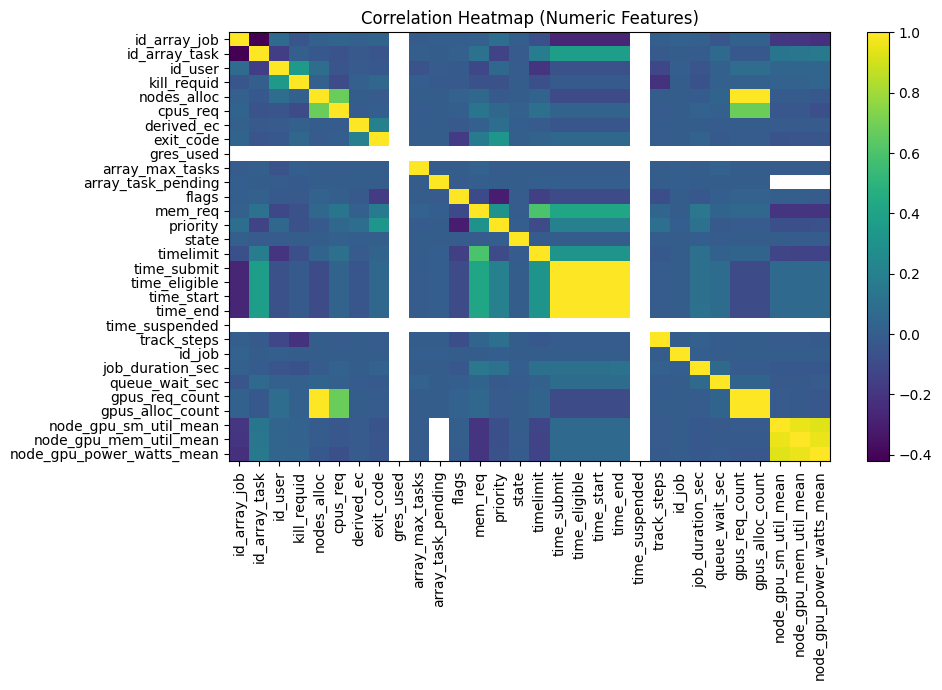

In [15]:
numeric_cols = scheduler_df.select_dtypes(include=[np.number]).columns.tolist()
corr = scheduler_df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")
plt.title("Correlation Heatmap (Numeric Features)")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar()
plt.tight_layout()
plt.show()

In [16]:
y = scheduler_df[TARGET_COL].copy()

drop_cols = [
    TARGET_COL,
    "id_job", "id_array_job", "id_array_task", "id_user",
    "nodelist", "node_key",
    "time_submit", "time_eligible", "time_start", "time_end",
]

X = scheduler_df.drop(columns=[c for c in drop_cols if c in scheduler_df.columns], errors="ignore")

print("X:", X.shape)
print("y:", y.shape)
display(X.head())

X: (217738, 28)
y: (217738,)


,kill_requid,nodes_alloc,cpus_req,derived_ec,exit_code,gres_req,gres_alloc,gres_used,array_max_tasks,array_task_pending,...,track_steps,tres_alloc,tres_req,job_duration_sec,queue_wait_sec,gpus_req_count,gpus_alloc_count,node_gpu_sm_util_mean,node_gpu_mem_util_mean,node_gpu_power_watts_mean
0,51671871839,0,1,0,256,NaN,NaN,NaN,0,0,...,0,NaN,"1=1,2=5000,4=1,5=1,1002=2",0,0,0,0,NaN,NaN,NaN
1,51671871839,1,1,0,0,gpu:volta:2,gpu:2,NaN,0,0,...,0,"1=1,2=9600,4=1,5=1,1002=2","1=1,2=9600,4=1,5=1,1002=2",3,0,2,2,15.366171,6.085502,52.329193
2,51671871839,1,4,32512,32512,gpu:volta:1,gpu:1,NaN,0,0,...,0,"1=4,2=38400,4=1,5=4,1002=1","1=4,2=38400,4=1,5=4,1002=1",1,1,1,1,NaN,NaN,NaN
3,16176946191,1,4,0,0,gpu:volta:1,gpu:1,NaN,0,0,...,0,"1=4,2=20000,4=1,5=4,1002=1","1=4,2=20000,4=1,5=4,1002=1",80,1,1,1,NaN,NaN,NaN
4,16176946191,1,4,0,0,gpu:volta:1,gpu:1,NaN,0,0,...,0,"1=4,2=20000,4=1,5=4,1002=1","1=4,2=20000,4=1,5=4,1002=1",512,0,1,1,NaN,NaN,NaN


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (174190, 28) (174190,)
Test : (43548, 28) (43548,)


In [18]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

Numeric: ['kill_requid', 'nodes_alloc', 'cpus_req', 'derived_ec', 'exit_code', 'gres_used', 'array_max_tasks', 'array_task_pending', 'flags', 'mem_req', 'priority', 'state', 'timelimit', 'time_suspended', 'track_steps', 'job_duration_sec', 'queue_wait_sec', 'gpus_req_count', 'gpus_alloc_count', 'node_gpu_sm_util_mean', 'node_gpu_mem_util_mean', 'node_gpu_power_watts_mean']
Categorical: ['gres_req', 'gres_alloc', 'constraints', 'partition', 'tres_alloc', 'tres_req']


In [19]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    }

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
    plt.figure(figsize=(7, 6))
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()

    return metrics

C:\Users\pc1\ml-env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['gres_used']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\pc1\ml-env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['gres_used']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



=== Dummy (Most Frequent) ===
                   precision    recall  f1-score   support

  LLMAPREDUCE:MAP       0.00      0.00      0.00       498
      LLSUB:BATCH       0.00      0.00      0.00      7372
LLSUB:INTERACTIVE       0.00      0.00      0.00      1501
            OTHER       0.78      1.00      0.88     34177

         accuracy                           0.78     43548
        macro avg       0.20      0.25      0.22     43548
     weighted avg       0.62      0.78      0.69     43548



<Figure size 700x600 with 0 Axes>

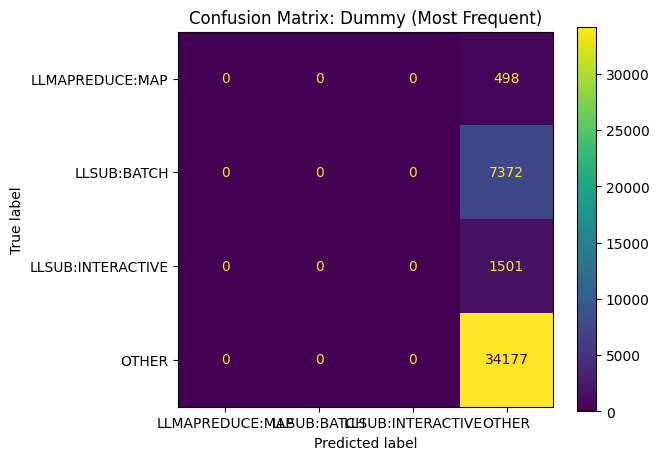

{'model': 'Dummy (Most Frequent)',
 'accuracy': 0.7848121612932856,
 'precision_macro': 0.1962030403233214,
 'recall_macro': 0.25,
 'f1_macro': 0.21985847539401737,
 'train_time_sec': 1.8407955169677734}

In [20]:
dummy = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", DummyClassifier(strategy="most_frequent"))
])

t0 = time.time()
dummy.fit(X_train, y_train)
dummy_time = time.time() - t0

dummy_metrics = evaluate_model("Dummy (Most Frequent)", dummy, X_test, y_test)
dummy_metrics["train_time_sec"] = dummy_time

dummy_metrics

C:\Users\pc1\ml-env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['gres_used']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\pc1\ml-env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['gres_used']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



=== Random Forest ===
                   precision    recall  f1-score   support

  LLMAPREDUCE:MAP       1.00      1.00      1.00       498
      LLSUB:BATCH       0.96      0.95      0.95      7372
LLSUB:INTERACTIVE       0.97      0.98      0.97      1501
            OTHER       0.99      0.99      0.99     34177

         accuracy                           0.98     43548
        macro avg       0.98      0.98      0.98     43548
     weighted avg       0.98      0.98      0.98     43548



<Figure size 700x600 with 0 Axes>

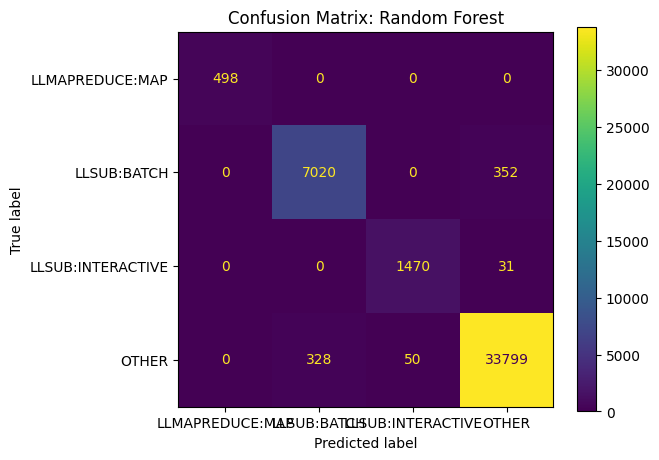

{'model': 'Random Forest',
 'accuracy': 0.9825250298521172,
 'precision_macro': 0.9778156346974155,
 'recall_macro': 0.9801346989309403,
 'f1_macro': 0.9789649075240952,
 'train_time_sec': 31.269705533981323}

In [21]:
rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - t0

rf_metrics = evaluate_model("Random Forest", rf, X_test, y_test)
rf_metrics["train_time_sec"] = rf_time

rf_metrics

Feature names: 1190
Importances : 1190


,feature,importance
9,num__priority,0.126289
109,cat__constraints_xeon-g6,0.093000
110,cat__constraints_xeon-g6&6248,0.092072
7,num__flags,0.091737
11,num__timelimit,0.058193
15,num__queue_wait_sec,0.051128
2,num__cpus_req,0.032957
8,num__mem_req,0.029084
14,num__job_duration_sec,0.028441
4,num__exit_code,0.024775


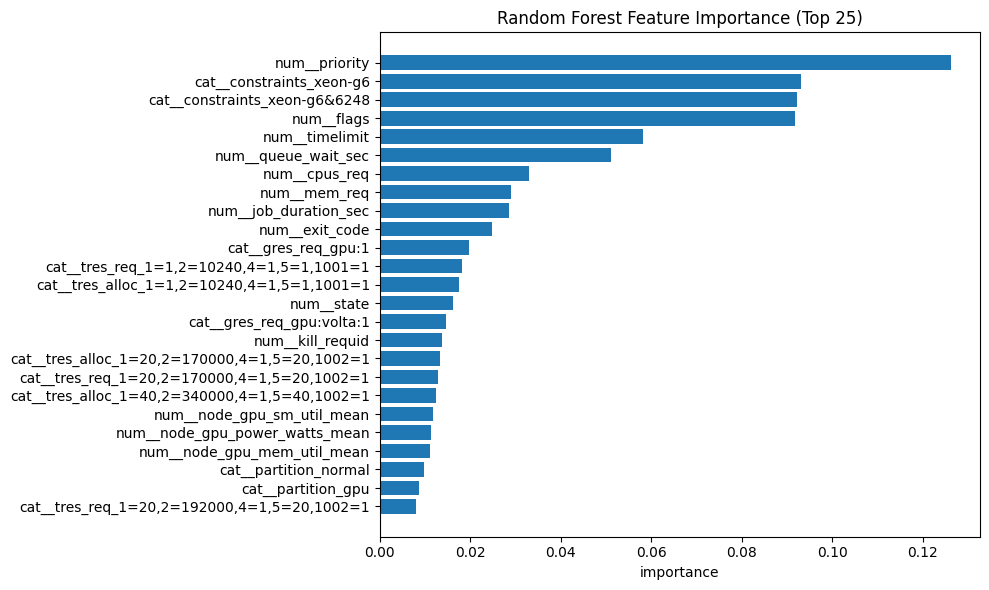

In [33]:
# RF Feature Importance (Robust / No length mismatch)

# 1) Get fitted preprocess from pipeline
pre = rf.named_steps["preprocess"]
clf = rf.named_steps["clf"]

# 2) Get feature names safely
feature_names = pre.get_feature_names_out()

# 3) Get importances
importances = clf.feature_importances_

print("Feature names:", len(feature_names))
print("Importances :", len(importances))

# 4) Safety check
if len(feature_names) != len(importances):
    raise ValueError(
        f"Mismatch: feature_names={len(feature_names)} vs importances={len(importances)}"
    )

# 5) Create importance DataFrame
fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(25)

display(fi)

# 6) Plot
plt.figure(figsize=(10, 6))
plt.barh(fi["feature"][::-1], fi["importance"][::-1])
plt.title("Random Forest Feature Importance (Top 25)")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

C:\Users\pc1\ml-env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['gres_used']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\pc1\ml-env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['gres_used']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



=== Linear SVM (LinearSVC) ===
                   precision    recall  f1-score   support

  LLMAPREDUCE:MAP       1.00      1.00      1.00       498
      LLSUB:BATCH       0.69      0.90      0.78      7372
LLSUB:INTERACTIVE       0.83      0.99      0.90      1501
            OTHER       0.98      0.91      0.94     34177

         accuracy                           0.91     43548
        macro avg       0.87      0.95      0.91     43548
     weighted avg       0.92      0.91      0.91     43548



<Figure size 700x600 with 0 Axes>

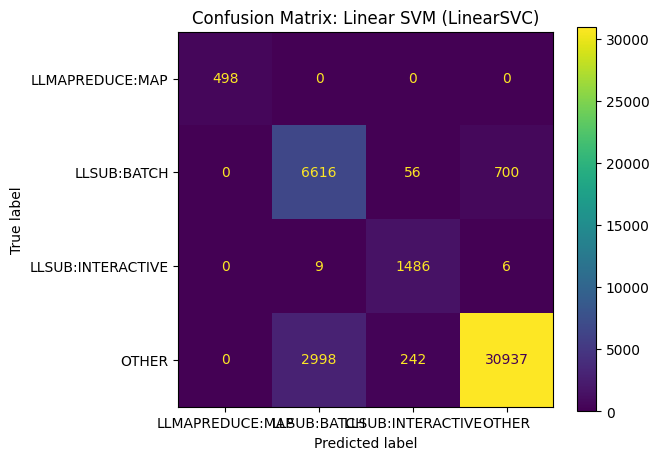

{'model': 'Linear SVM (LinearSVC)',
 'accuracy': 0.9078947368421053,
 'precision_macro': 0.8745419285342996,
 'recall_macro': 0.9481639688561943,
 'f1_macro': 0.9058372425880452,
 'train_time_sec': 58.3530433177948}

In [24]:
svm = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=5000
    ))
])

t0 = time.time()
svm.fit(X_train, y_train)
svm_time = time.time() - t0

svm_metrics = evaluate_model("Linear SVM (LinearSVC)", svm, X_test, y_test)
svm_metrics["train_time_sec"] = svm_time

svm_metrics

In [25]:
X_train_proc = preprocess.fit_transform(X_train)
X_test_proc = preprocess.transform(X_test)

label_to_id = {label: i for i, label in enumerate(sorted(y.unique()))}
id_to_label = {i: label for label, i in label_to_id.items()}

y_train_id = y_train.map(label_to_id).values
y_test_id = y_test.map(label_to_id).values

num_classes = len(label_to_id)

print("X_train_proc:", X_train_proc.shape)
print("X_test_proc:", X_test_proc.shape)
print("Classes:", label_to_id)

C:\Users\pc1\ml-env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['gres_used']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\pc1\ml-env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['gres_used']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


X_train_proc: (174190, 1190)
X_test_proc: (43548, 1190)
Classes: {'LLMAPREDUCE:MAP': 0, 'LLSUB:BATCH': 1, 'LLSUB:INTERACTIVE': 2, 'OTHER': 3}


In [26]:
tf.random.set_seed(42)

ann = keras.Sequential([
    keras.layers.Input(shape=(X_train_proc.shape[1],)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(num_classes, activation="softmax")
])

ann.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

t0 = time.time()
history = ann.fit(
    X_train_proc, y_train_id,
    validation_split=0.2,
    epochs=20,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)
ann_time = time.time() - t0

ann_time

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7612 - loss: 0.6354 - val_accuracy: 0.9114 - val_loss: 0.1882
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9075 - loss: 0.1911 - val_accuracy: 0.9224 - val_loss: 0.1620
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9164 - loss: 0.1676 - val_accuracy: 0.9230 - val_loss: 0.1545
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9205 - loss: 0.1590 - val_accuracy: 0.9241 - val_loss: 0.1499
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9213 - loss: 0.1547 - val_accuracy: 0.9270 - val_loss: 0.1465
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9236 - loss: 0.1508 - val_accuracy: 0.9275 - val_loss: 0.1445
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9258 - loss: 0.1474 - val_accuracy: 0.9302 - val_loss: 0.1415
Epoch 8/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9274 - loss: 0.1450 - val_accuracy: 0.

20.784098386764526

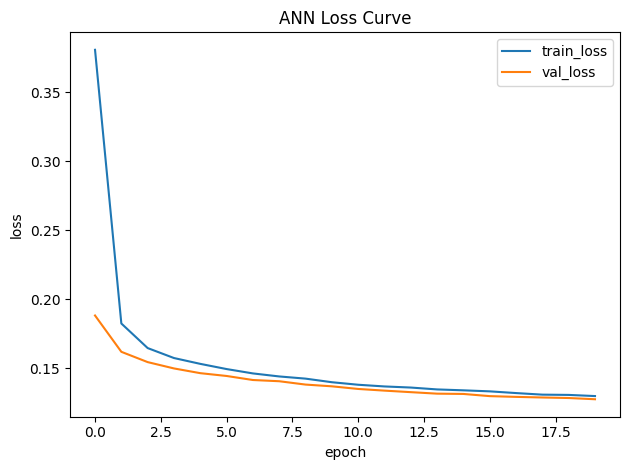

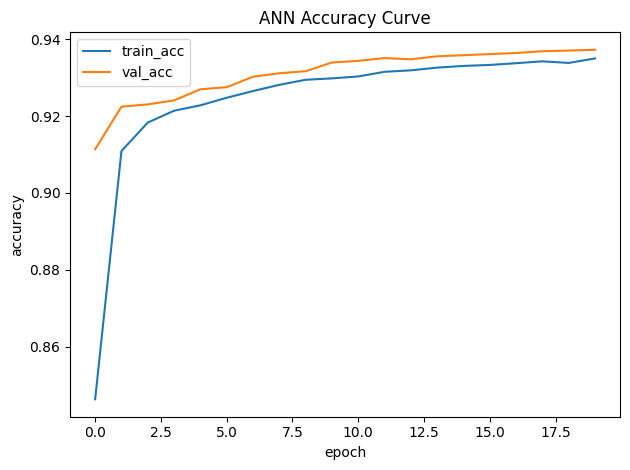

In [27]:
plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("ANN Loss Curve")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("ANN Accuracy Curve")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.tight_layout()
plt.show()

1361/1361 ━━━━━━━━━━━━━━━━━━━━ 1s 802us/step

=== ANN (Keras) ===
                   precision    recall  f1-score   support

  LLMAPREDUCE:MAP       1.00      1.00      1.00       498
      LLSUB:BATCH       0.77      0.94      0.84      7372
LLSUB:INTERACTIVE       0.94      0.98      0.96      1501
            OTHER       0.98      0.94      0.96     34177

         accuracy                           0.94     43548
        macro avg       0.92      0.96      0.94     43548
     weighted avg       0.95      0.94      0.94     43548



<Figure size 700x600 with 0 Axes>

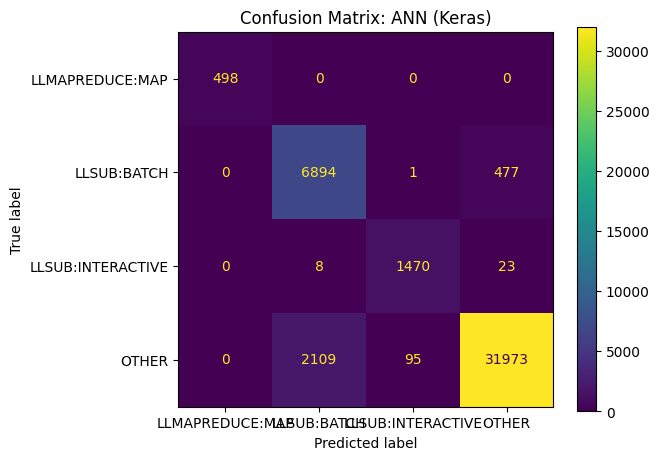

{'model': 'ANN (Keras)',
 'accuracy': 0.93770092771195,
 'precision_macro': 0.9220912078958876,
 'recall_macro': 0.9625048384003722,
 'f1_macro': 0.9399063541818746,
 'train_time_sec': 20.784098386764526}

In [28]:
y_prob = ann.predict(X_test_proc)
y_pred_id = np.argmax(y_prob, axis=1)
y_pred = pd.Series(y_pred_id).map(id_to_label).values

ann_metrics = {
    "model": "ANN (Keras)",
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "train_time_sec": ann_time
}

print("\n=== ANN (Keras) ===")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
plt.figure(figsize=(7, 6))
disp.plot(values_format="d")
plt.title("Confusion Matrix: ANN (Keras)")
plt.tight_layout()
plt.show()

ann_metrics

In [29]:
results = pd.DataFrame([dummy_metrics, rf_metrics, svm_metrics, ann_metrics])
display(results.sort_values("accuracy", ascending=False))

,model,accuracy,precision_macro,recall_macro,f1_macro,train_time_sec
1,Random Forest,0.982525,0.977816,0.980135,0.978965,31.269706
3,ANN (Keras),0.937701,0.922091,0.962505,0.939906,20.784098
2,Linear SVM (LinearSVC),0.907895,0.874542,0.948164,0.905837,58.353043
0,Dummy (Most Frequent),0.784812,0.196203,0.250000,0.219858,1.840796


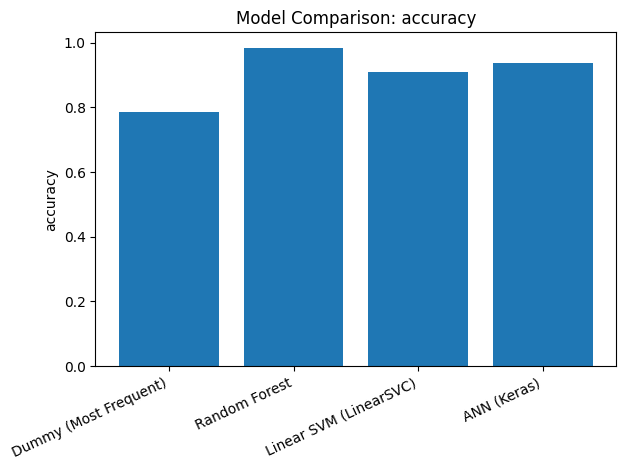

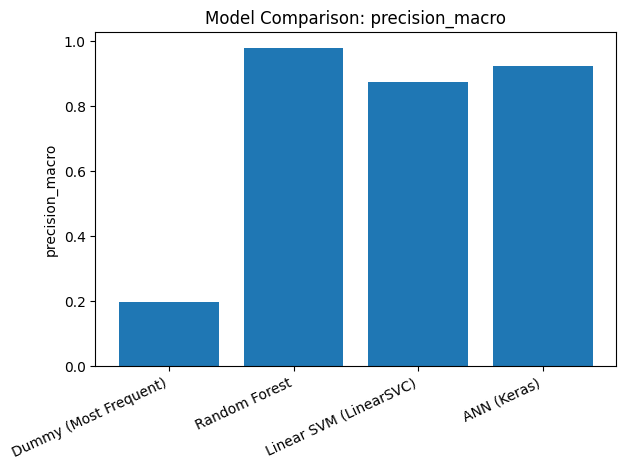

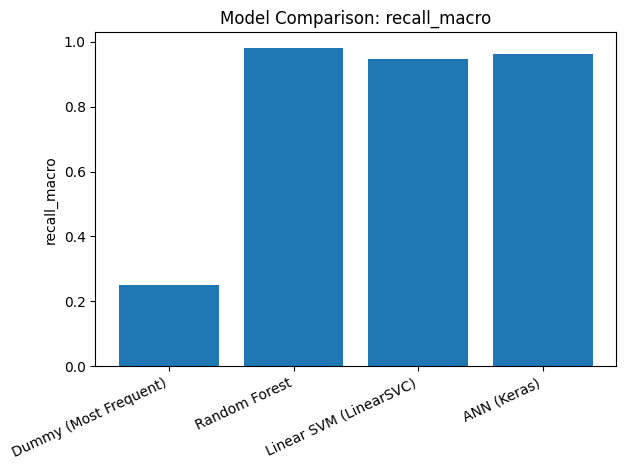

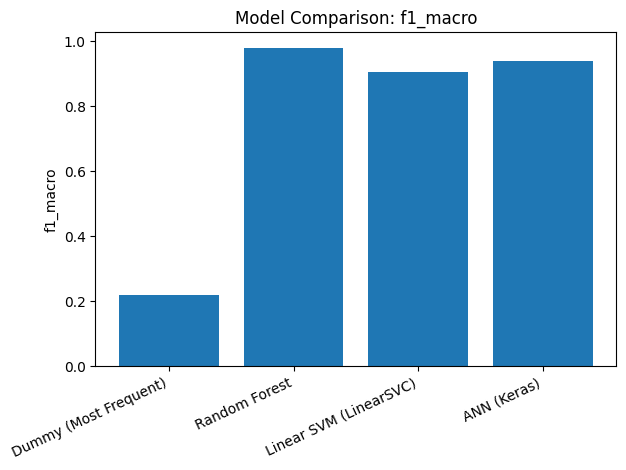

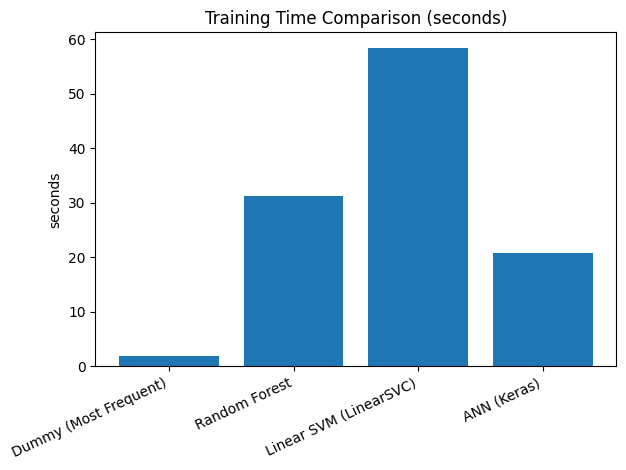

In [32]:
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

for m in metrics_to_plot:
    plt.figure()
    plt.bar(results["model"], results[m])
    plt.title(f"Model Comparison: {m}")
    plt.ylabel(m)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
plt.bar(results["model"], results["train_time_sec"])
plt.title("Training Time Comparison (seconds)")
plt.ylabel("seconds")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [34]:
# Save cleaned dataset deliverable
scheduler_df.to_csv("cleaned_labeled_workload_dataset.csv", index=False)
print("Saved: cleaned_labeled_workload_dataset.csv")

Saved: cleaned_labeled_workload_dataset.csv


In [36]:
# Scheduler improvement documentation 

best_model = results.sort_values("f1_macro", ascending=False).iloc[0]["model"]

doc = f"""
SCHEDULER IMPROVEMENT DOCUMENTATION (Workload Classification)

Goal:
Predict workload type (job_type) from resource signals (CPU, memory, GPU telemetry, duration)
to enable resource-aware placement and reduce contention.

Pipeline Summary:
1) Loaded scheduler logs and DCGM GPU telemetry logs
2) Cleaned data (dedupe, valid job times, engineered wait time and duration)
3) Extracted GPU request counts from GRES fields
4) Merged node-level GPU telemetry (SM utilization, memory utilization, power)
5) Trained real-time-capable classifiers (Dummy baseline, Random Forest, Linear SVM, ANN)
6) Evaluated via accuracy, precision, recall, F1 (macro) + confusion matrices
7) Compared models visually and selected best model by F1_macro

Best model (by macro F1): {best_model}

Deployment Idea (Resource-aware scheduling):
- If predicted type is GPU-heavy → place on GPU nodes with high free GPU memory + low SM contention
- If predicted type is memory-heavy → place on nodes with highest RAM headroom
- If predicted type is CPU-heavy → place on CPU-dense nodes and pack jobs to reduce fragmentation
- Use predicted class to guide queue priorities and node selection to reduce contention

Expected Impact:
- Improved utilization (better fit between job type and node capability)
- Lower queue times due to reduced resource contention
- Better GPU efficiency when telemetry is used for placement decisions
"""
print(doc)


SCHEDULER IMPROVEMENT DOCUMENTATION (Workload Classification)

Goal:
Predict workload type (job_type) from resource signals (CPU, memory, GPU telemetry, duration)
to enable resource-aware placement and reduce contention.

Pipeline Summary:
1) Loaded scheduler logs and DCGM GPU telemetry logs
2) Cleaned data (dedupe, valid job times, engineered wait time and duration)
3) Extracted GPU request counts from GRES fields
4) Merged node-level GPU telemetry (SM utilization, memory utilization, power)
5) Trained real-time-capable classifiers (Dummy baseline, Random Forest, Linear SVM, ANN)
6) Evaluated via accuracy, precision, recall, F1 (macro) + confusion matrices
7) Compared models visually and selected best model by F1_macro

Best model (by macro F1): Random Forest

Deployment Idea (Resource-aware scheduling):
- If predicted type is GPU-heavy → place on GPU nodes with high free GPU memory + low SM contention
- If predicted type is memory-heavy → place on nodes with highest RAM headroom
- I